In [1]:
!pip install seaborn
!pip install torch
!pip install torchvision
!pip install scikit-learn

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
!pip install timm


     |████████████████████████████████| 549 kB 17.2 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 814 kB/s  eta 0:00:01
     |████████████████████████████████| 677 kB 38.9 MB/s eta 0:00:01
     |████████████████████████████████| 40 kB 1.4 MB/s  eta 0:00:01
  Attempting uninstall: packaging
    Found existing installation: packaging 20.8
    Uninstalling packaging-20.8:
      Successfully uninstalled packaging-20.8
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [3]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import os
import sys

In [4]:
import torch
import torch.nn as nn
import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import os

# --- CONFIGURAÇÃO ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DEFINIR A CLASSE DO MODELO ---
class ConvNeXtSingleFrame(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base_model = timm.create_model('convnext_base', pretrained=True, num_classes=0)  # remove head
        self.backbone = base_model
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = self.dropout(x)
        return self.fc(x)

# --- CAMINHO E TRANSFORMAÇÕES ---
TEST_DIR = "./face_extraction/faceforensis_face_extract/test/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes
num_classes = len(class_names)

# --- CARREGAR O MODELO ---
model = ConvNeXtSingleFrame(num_classes=num_classes).to(device)
model.load_state_dict(torch.load("best_model_convnext_v2.pth", map_location=device))
model.eval()

# --- AVALIAÇÃO ---
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# --- RELATÓRIO DE CLASSIFICAÇÃO ---
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=class_names))


Downloading: "https://dl.fbaipublicfiles.com/convnext/convnext_base_1k_224_ema.pth" to /root/.cache/torch/hub/checkpoints/convnext_base_1k_224_ema.pth


                   precision    recall  f1-score   support

DeepFakeDetection       1.00      0.91      0.95      1000
      FaceShifter       0.92      0.74      0.82      1000
         FaceSwap       0.94      0.63      0.75      1000
    NeuraTextures       0.82      0.65      0.73      1000
        deepfakes       0.98      0.64      0.78       999
        face2face       0.99      0.78      0.87      1000
         original       0.40      0.94      0.56      1000

         accuracy                           0.76      6999
        macro avg       0.86      0.76      0.78      6999
     weighted avg       0.86      0.76      0.78      6999



In [5]:
!pip install captum

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


✅ Figura salva como 'explicabilidade_grid_convnext.png'


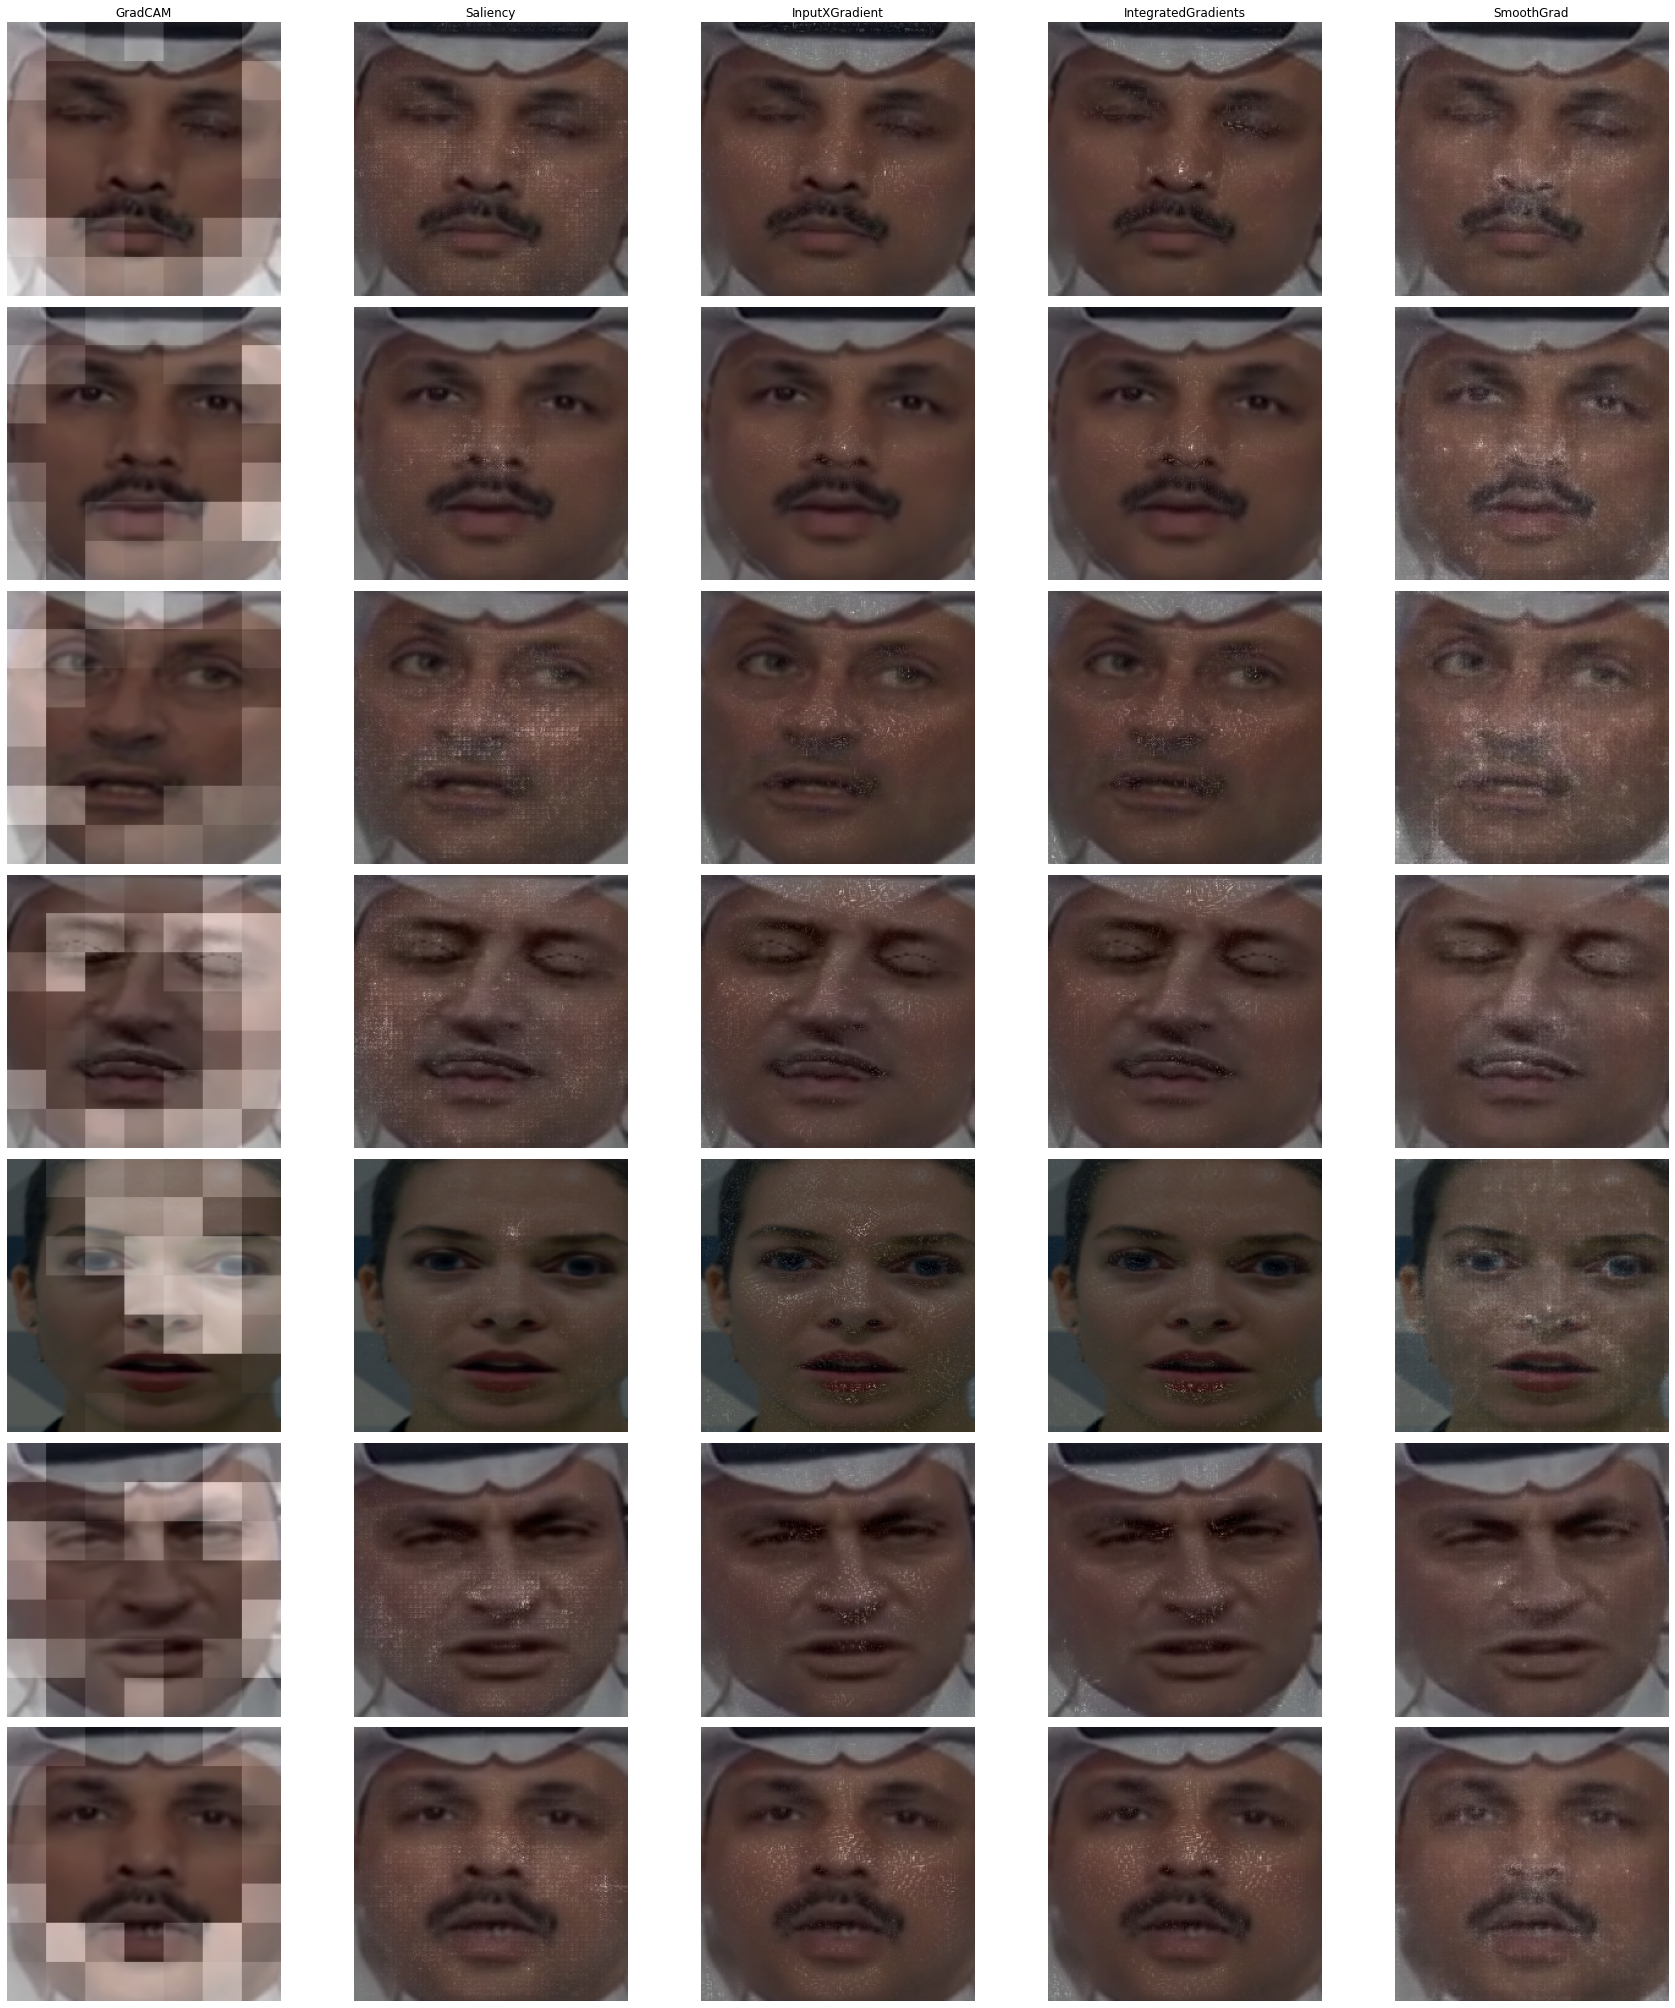

In [21]:
from PIL import Image
from captum.attr import LayerGradCam, Saliency, IntegratedGradients, InputXGradient
from captum.attr import LayerAttribution
from captum.attr import NoiseTunnel
    
def load_image_tensor(img_path):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0)
    img_tensor.requires_grad_()  # Adicionado para evitar o warning do Captum
    img_np = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
    return img_tensor, img_np

def normalize_attr(attr):
    attr = np.maximum(attr, 0)
    if np.max(attr) > 0:
        attr = attr / np.max(attr)
    return np.stack([attr] * 3, axis=-1)

def generate_visualizations(model, img_tensor, img_np, label):
    torch.cuda.empty_cache()  # liberação ativa

    target_layer = list(model.backbone.stages[-1].children())[-1]
    
    gradcam = LayerGradCam(model, target_layer)
    gradcam_attr = gradcam.attribute(img_tensor, target=label)
    gradcam_attr = LayerAttribution.interpolate(gradcam_attr, (224, 224))
    gradcam_attr = gradcam_attr.squeeze().detach().cpu().numpy()

    saliency = Saliency(model)
    saliency_attr = saliency.attribute(img_tensor, target=label)
    saliency_attr = saliency_attr.squeeze().abs().detach().cpu().numpy().mean(axis=0)

    inputxgrad = InputXGradient(model)
    inputxgrad_attr = inputxgrad.attribute(img_tensor, target=label)
    inputxgrad_attr = inputxgrad_attr.squeeze().detach().cpu().numpy().mean(axis=0)

    integrated = IntegratedGradients(model)
    integrated_attr = integrated.attribute(img_tensor, target=label, n_steps=5)
    integrated_attr = integrated_attr.squeeze().detach().cpu().numpy().mean(axis=0)

    smoothgrad = NoiseTunnel(saliency)
    smoothgrad_attr = smoothgrad.attribute(img_tensor, nt_type="smoothgrad", target=label)
    smoothgrad_attr = smoothgrad_attr.squeeze().detach().cpu().numpy().mean(axis=0)

    vis = []
    for attr in [gradcam_attr, saliency_attr, inputxgrad_attr, integrated_attr, smoothgrad_attr]:
        blended = np.clip(img_np * 0.5 + normalize_attr(attr) * 0.5, 0, 1)
        vis.append(blended)

    torch.cuda.empty_cache()  # libera ao final também
    return vis




# Classes e imagens
image_groups = {
    "ORIGINAL": [
        "./face_extraction/faceforensis_face_extract/train/original/original_000_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/original/original_004_frame2.png",
        "./face_extraction/faceforensis_face_extract/train/original/original_006_frame1.png",
        "./face_extraction/faceforensis_face_extract/train/original/original_011_frame4.png",
        "./face_extraction/faceforensis_face_extract/train/original/original_018_frame3.png",
    ],
    "FACE2FACE": [
        "./face_extraction/faceforensis_face_extract/train/face2face/Face2Face_000_003_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/face2face/Face2Face_002_006_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/face2face/Face2Face_006_002_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/face2face/Face2Face_010_005_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/face2face/Face2Face_017_803_frame3.png",
    ],
    "FACESHIFTER": [
        "./face_extraction/faceforensis_face_extract/train/FaceShifter/FaceShifter_000_003_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceShifter/FaceShifter_002_006_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceShifter/FaceShifter_006_002_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceShifter/FaceShifter_010_005_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/FaceShifter/FaceShifter_017_803_frame3.png",
    ],
    "FACESWAP": [
        "./face_extraction/faceforensis_face_extract/train/FaceSwap/FaceSwap_000_003_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceSwap/FaceSwap_002_006_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceSwap/FaceSwap_006_002_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/FaceSwap/FaceSwap_010_005_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/FaceSwap/FaceSwap_017_803_frame3.png",
    ],
    "DEEPFAKEDETECTION": [
        "./face_extraction/faceforensis_face_extract/train/DeepFakeDetection/DeepFakeDetection_01_02__talking_against_wall__YVGY8LOK_frame4.png",
        "./face_extraction/faceforensis_face_extract/train/DeepFakeDetection/DeepFakeDetection_01_04__talking_angry_couch__0XUW13RW_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/DeepFakeDetection/DeepFakeDetection_01_15__kitchen_still__02HILKYO_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/DeepFakeDetection/DeepFakeDetection_01_21__walk_down_hall_angry__03X7CELV_frame1.png",
        "./face_extraction/faceforensis_face_extract/train/DeepFakeDetection/DeepFakeDetection_01_27__meeting_serious__ZYCZ30C0_frame3.png",
    ],
    "DEEPFAKES": [
        "./face_extraction/faceforensis_face_extract/train/deepfakes/Deepfakes_000_003_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/deepfakes/Deepfakes_002_006_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/deepfakes/Deepfakes_006_002_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/deepfakes/Deepfakes_010_005_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/deepfakes/Deepfakes_017_803_frame3.png",
    ],
    "NEURALTEXTURES": [
        "./face_extraction/faceforensis_face_extract/train/NeuraTextures/NeuralTextures_000_003_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/NeuraTextures/NeuralTextures_002_006_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/NeuraTextures/NeuralTextures_006_002_frame5.png",
        "./face_extraction/faceforensis_face_extract/train/NeuraTextures/NeuralTextures_010_005_frame3.png",
        "./face_extraction/faceforensis_face_extract/train/NeuraTextures/NeuralTextures_017_803_frame3.png",
    ],
}

def show_explanations_grid():
    techniques = ["GradCAM", "Saliency", "InputXGradient", "IntegratedGradients", "SmoothGrad"]
    fig, axs = plt.subplots(len(image_groups), len(techniques), figsize=(5*len(techniques), 4*len(image_groups)))
    for row_idx, (label, image_list) in enumerate(image_groups.items()):
        img_tensor, img_np = load_image_tensor(image_list[0])  # primeira imagem da classe
        img_tensor = img_tensor.to(device)
        pred = torch.argmax(torch.nn.functional.softmax(model(img_tensor), dim=1)).item()
        vis_list = generate_visualizations(model, img_tensor, img_np, pred)
        for col_idx, vis in enumerate(vis_list):
            axs[row_idx, col_idx].imshow(vis)
            axs[row_idx, col_idx].axis('off')
            if row_idx == 0:
                axs[row_idx, col_idx].set_title(techniques[col_idx], fontsize=12)
            if col_idx == 0:
                axs[row_idx, col_idx].set_ylabel(label, fontsize=12)
                
        del img_tensor, vis_list
        torch.cuda.empty_cache()
    plt.tight_layout()
    plt.savefig("explicabilidade_grid_convnext.png")  # Salva o resultado como imagem
    print("✅ Figura salva como 'explicabilidade_grid_convnext.png'")
    plt.show(block=True)

# Executar
if __name__ == "__main__":
    show_explanations_grid()

In [6]:
!pip install pandas scikit-learn matplotlib seaborn openpyxl joblib xlrd

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [7]:
pip install scikit-image


You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
from skimage.segmentation import slic
from scipy.stats import entropy
import os
import pandas as pd
import matplotlib.pyplot as plt
from skimage.transform import resize
from captum.attr import IntegratedGradients, Saliency, InputXGradient, NoiseTunnel
from skimage.transform import resize
import gc


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATASET_ROOT = "./face_extraction/faceforensis_face_extract/test/"
class_names = ["DeepFakeDetection", "FaceShifter", "FaceSwap", "NeuraTextures", "deepfakes", "face2face", "original"]
explic_methods = ["Saliency", "InputXGradient", "IntegratedGradients", "SmoothGrad", "GradCAM"]

print("Iniciando.")


def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ajuste para ConvNeXt
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)
    np_img = np.array(image.resize((224, 224))) / 255.0
    return tensor, np_img

def make_gradcam(model, img_tensor, target_layer='backbone.stages.3.blocks.2.conv_dw'):
    gradients, activations = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_module = dict(model.named_modules())[target_layer]

    fh = target_module.register_forward_hook(forward_hook)
    bh = target_module.register_full_backward_hook(backward_hook)

    img_tensor.requires_grad_(True)
    output = model(img_tensor)
    class_idx = torch.argmax(output)
    loss = output[0, class_idx]
    model.zero_grad()
    loss.backward()

    grad = gradients[0]
    act = activations[0]
    pooled_grad = torch.mean(grad, dim=[0, 2, 3])
    for i in range(act.shape[1]):
        act[:, i, :, :] *= pooled_grad[i]
    heatmap = act.mean(dim=1).squeeze().detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-12)

    fh.remove()
    bh.remove()
    return heatmap

def get_saliency_map(method, model, input_tensor, target_idx):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    if method == "Saliency":
        explainer = Saliency(model)
        attributions = explainer.attribute(input_tensor, target=target_idx)
    elif method == "InputXGradient":
        explainer = InputXGradient(model)
        attributions = explainer.attribute(input_tensor, target=target_idx)
    elif method == "IntegratedGradients":
        explainer = IntegratedGradients(model)
        attributions = explainer.attribute(input_tensor, target=target_idx, n_steps=10, internal_batch_size=5)
    elif method == "SmoothGrad":
        saliency = Saliency(model)
        explainer = NoiseTunnel(saliency)
        attributions = explainer.attribute(input_tensor, nt_type='smoothgrad', nt_samples=15, target=target_idx)
    elif method == "GradCAM":
        cam = make_gradcam(model, input_tensor)
        cam_resized = resize(cam, (224, 224), mode='reflect', anti_aliasing=True)
        return cam_resized
    else:
        raise ValueError(f"Método {method} desconhecido.")

    attr_np = attributions.detach().cpu().numpy().squeeze()
    attr_np = np.abs(attr_np).sum(axis=0)
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-12)
    return attr_np

def salience_entropy(smap):
    smap = smap / (np.sum(smap) + 1e-12)
    return entropy(smap.flatten() + 1e-12)

def reaction_to_noise(model, img_tensor, salmap):
    noisy = img_tensor + torch.normal(0, 0.05, img_tensor.shape).to(DEVICE)
    output = model(noisy)
    target_idx = torch.argmax(output).item()
    noisy_salmap = get_saliency_map("GradCAM", model, noisy, target_idx)
    
    # Redimensiona o mapa ruidoso para o tamanho do original
    noisy_salmap_resized = resize(noisy_salmap, salmap.shape, mode='reflect', anti_aliasing=True)
    
    return np.mean(np.abs(salmap - noisy_salmap_resized))

def geometrical_robustness(model, raw_img, salmap):
    flipped = np.flip(raw_img, axis=1).copy()  # flip horizontal
    flipped_tensor = torch.from_numpy(flipped.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    flipped_tensor.requires_grad_(True)

    output = model(flipped_tensor)
    target_idx = torch.argmax(output).item()
    flipped_salmap = get_saliency_map("GradCAM", model, flipped_tensor, target_idx)

    # Redimensiona para o shape original do mapa
    flipped_salmap_resized = resize(flipped_salmap, salmap.shape, mode='reflect', anti_aliasing=True)

    return np.mean(np.abs(salmap - flipped_salmap_resized))

def accuracy_over_segmentation(model, image, saliency_map, segments=50):
    salmap_resized = resize(saliency_map, (image.shape[0], image.shape[1]), mode='reflect', anti_aliasing=True)
    img_uint8 = (image * 255).astype(np.uint8)
    segs = slic(img_uint8, n_segments=segments, compactness=20, enforce_connectivity=True, start_label=0)
    relevance = np.array([np.mean(salmap_resized[segs == i]) for i in range(np.max(segs) + 1)])
    top_k = np.argsort(relevance)[-int(segments * 0.2):]
    mask = np.isin(segs, top_k).astype(np.float32)
    if mask.ndim == 2:
        mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
    degraded = image * (1 - mask)
    with torch.no_grad():
        orig_pred = model(torch.from_numpy(image.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE))[0]
        degr_pred = model(torch.from_numpy(degraded.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE))[0]
    return np.abs(orig_pred.cpu().numpy() - degr_pred.cpu().numpy()).mean(), segs

print("Modelo carregado com sucesso.")

image_files = []
image_labels = []
for folder in class_names:
    folder_path = os.path.join(DATASET_ROOT, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))])
    for f in files:
        image_files.append(os.path.join(folder_path, f))
        image_labels.append(folder)


resultados = []
n_rows = len(image_files)
n_cols = len(explic_methods) + 1

# fig, axs = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))

for row, (path, label) in enumerate(zip(image_files, image_labels)):
    img_tensor, raw_img = preprocess_image(path)
    output = model(img_tensor)
    pred_idx = torch.argmax(output, dim=1).item()

    for col, method in enumerate(explic_methods, start=1):
        salmap = get_saliency_map(method, model, img_tensor, pred_idx)
        entropy_val = salience_entropy(salmap)
        noise_val = reaction_to_noise(model, img_tensor, salmap)
        geo_val = geometrical_robustness(model, raw_img, salmap)
        aos_val, _ = accuracy_over_segmentation(model, raw_img, salmap)

        resultado = {
            "imagem": os.path.basename(path),
            "classe_real": label,
            "classe_predita": class_names[pred_idx],
            "metodo_explicabilidade": method,
            "entropia": entropy_val,
            "ruido": noise_val,
            "geo": geo_val,
            "aos": aos_val
        }
        resultados.append(resultado)

        print(f"[{row+1}/{n_rows}] Imagem: {os.path.basename(path)} | Técnica: {method} | Entropia: {entropy_val:.4f} | Ruído: {noise_val:.4f} | Geo: {geo_val:.4f} | AOS: {aos_val:.4f}")

    del img_tensor, raw_img, output
    torch.cuda.empty_cache()
    gc.collect()



#plt.tight_layout()
#plt.savefig("grid_explicabilidade_todas_imagens.png", dpi=300)
#print("Grid salvo como grid_explicabilidade_todas_imagens.png")

df_resultados = pd.DataFrame(resultados)
df_resultados.to_excel("resultados_explicabilidade_todas_imagens_inception.xlsx", index=False)
print("Planilha salva como resultados_explicabilidade_todas_imagens_inception.xlsx")

Iniciando.
Modelo carregado com sucesso.
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: Saliency | Entropia: 10.5255 | Ruído: 0.3997 | Geo: 0.4866 | AOS: 1.3479
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: InputXGradient | Entropia: 10.3997 | Ruído: 0.4020 | Geo: 0.4752 | AOS: 1.4047
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: IntegratedGradients | Entropia: 10.3843 | Ruído: 0.3876 | Geo: 0.4793 | AOS: 1.5594
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: SmoothGrad | Entropia: 10.6100 | Ruído: 0.3650 | Geo: 0.4011 | AOS: 1.7272
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: GradCAM | Entropia: 10.4300 | Ruído: 0.2342 | Geo: 0.3348 | AOS: 1.6131
[2/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame2.png | Técnica: Saliency | Entropia: 10.5158 | Ruído

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
from skimage.segmentation import slic
from scipy.stats import entropy
import os
import pandas as pd
import matplotlib.pyplot as plt
from skimage.transform import resize
from captum.attr import IntegratedGradients, Saliency, InputXGradient, NoiseTunnel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATASET_ROOT = "./face_extraction/faceforensis_face_extract/test/"
class_names = ["DeepFakeDetection", "FaceShifter", "FaceSwap", "NeuraTextures", "deepfakes", "face2face", "original"]
explic_methods = ["Saliency", "InputXGradient", "IntegratedGradients", "SmoothGrad", "GradCAM"]

print("Iniciando.")

def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ajuste para ConvNeXt
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)
    np_img = np.array(image.resize((224, 224))) / 255.0
    return tensor, np_img

def make_gradcam(model, img_tensor, target_layer='backbone.stages.3.blocks.2.conv_dw'):
    gradients, activations = [], []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_module = dict(model.named_modules())[target_layer]

    fh = target_module.register_forward_hook(forward_hook)
    bh = target_module.register_full_backward_hook(backward_hook)

    img_tensor.requires_grad_(True)
    output = model(img_tensor)
    class_idx = torch.argmax(output)
    loss = output[0, class_idx]
    model.zero_grad()
    loss.backward()

    grad = gradients[0]
    act = activations[0]
    pooled_grad = torch.mean(grad, dim=[0, 2, 3])
    for i in range(act.shape[1]):
        act[:, i, :, :] *= pooled_grad[i]
    heatmap = act.mean(dim=1).squeeze().detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-12)

    fh.remove()
    bh.remove()
    return heatmap


def get_saliency_map(method, model, input_tensor, target_idx):
    input_tensor = input_tensor.clone().detach().requires_grad_(True)

    if method == "Saliency":
        explainer = Saliency(model)
        attributions = explainer.attribute(input_tensor, target=target_idx)
    elif method == "InputXGradient":
        explainer = InputXGradient(model)
        attributions = explainer.attribute(input_tensor, target=target_idx)
    elif method == "IntegratedGradients":
        explainer = IntegratedGradients(model)
        attributions = explainer.attribute(input_tensor, target=target_idx, n_steps=10)
    elif method == "SmoothGrad":
        saliency = Saliency(model)
        explainer = NoiseTunnel(saliency)
        attributions = explainer.attribute(input_tensor, nt_type='smoothgrad', nt_samples=25, target=target_idx)
    elif method == "GradCAM":
        cam = make_gradcam(model, input_tensor)
        cam_resized = resize(cam, (224, 224), mode='reflect', anti_aliasing=True)
        return cam_resized
    else:
        raise ValueError(f"Método {method} desconhecido.")

    attr_np = attributions.detach().cpu().numpy().squeeze()
    attr_np = np.abs(attr_np).sum(axis=0)
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-12)
    return attr_np

def salience_entropy(smap):
    smap = smap / (np.sum(smap) + 1e-12)
    return entropy(smap.flatten() + 1e-12)

def reaction_to_noise(model, img_tensor, salmap):
    noisy = img_tensor + torch.normal(0, 0.05, img_tensor.shape).to(DEVICE)
    output = model(noisy)
    target_idx = torch.argmax(output).item()
    noisy_salmap = get_saliency_map("GradCAM", model, noisy, target_idx)
    noisy_salmap_resized = resize(noisy_salmap, salmap.shape, mode='reflect', anti_aliasing=True)
    return np.mean(np.abs(salmap - noisy_salmap_resized))

def geometrical_robustness(model, raw_img, salmap):
    flipped = np.flip(raw_img, axis=1).copy()
    flipped_tensor = torch.from_numpy(flipped.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
    flipped_tensor.requires_grad_(True)
    output = model(flipped_tensor)
    target_idx = torch.argmax(output).item()
    flipped_salmap = get_saliency_map("GradCAM", model, flipped_tensor, target_idx)
    flipped_salmap_resized = resize(flipped_salmap, salmap.shape, mode='reflect', anti_aliasing=True)
    return np.mean(np.abs(salmap - flipped_salmap_resized))

def accuracy_over_segmentation(model, image, saliency_map, segments=50):
    salmap_resized = resize(saliency_map, (image.shape[0], image.shape[1]), mode='reflect', anti_aliasing=True)
    img_uint8 = (image * 255).astype(np.uint8)
    segs = slic(img_uint8, n_segments=segments, compactness=20, enforce_connectivity=True, start_label=0)
    relevance = np.array([np.mean(salmap_resized[segs == i]) for i in range(np.max(segs) + 1)])
    top_k = np.argsort(relevance)[-int(segments * 0.2):]
    mask = np.isin(segs, top_k).astype(np.float32)
    if mask.ndim == 2:
        mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)
    degraded = image * (1 - mask)
    with torch.no_grad():
        orig_pred = model(torch.from_numpy(image.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE))[0]
        degr_pred = model(torch.from_numpy(degraded.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE))[0]
    return np.abs(orig_pred.cpu().numpy() - degr_pred.cpu().numpy()).mean(), segs

print("Modelo carregado com sucesso.")

# Avaliação de todas as imagens
image_files = []
image_labels = []
for folder in class_names:
    folder_path = os.path.join(DATASET_ROOT, folder)
    files = sorted([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))])
    for f in files:
        image_files.append(os.path.join(folder_path, f))
        image_labels.append(folder)

resultados = []
n_rows = len(image_files)
n_cols = len(explic_methods) + 1

for row, (path, label) in enumerate(zip(image_files, image_labels)):
    img_tensor, raw_img = preprocess_image(path)
    output = model(img_tensor)
    pred_idx = torch.argmax(output, dim=1).item()

    for col, method in enumerate(explic_methods, start=1):
        salmap = get_saliency_map(method, model, img_tensor, pred_idx)
        entropy_val = salience_entropy(salmap)
        noise_val = reaction_to_noise(model, img_tensor, salmap)
        geo_val = geometrical_robustness(model, raw_img, salmap)
        aos_val, _ = accuracy_over_segmentation(model, raw_img, salmap)

        resultado = {
            "imagem": os.path.basename(path),
            "classe_real": label,
            "classe_predita": class_names[pred_idx],
            "metodo_explicabilidade": method,
            "entropia": entropy_val,
            "ruido": noise_val,
            "geo": geo_val,
            "aos": aos_val
        }
        resultados.append(resultado)

        print(f"[{row+1}/{n_rows}] Imagem: {os.path.basename(path)} | Técnica: {method} | Entropia: {entropy_val:.4f} | Ruído: {noise_val:.4f} | Geo: {geo_val:.4f} | AOS: {aos_val:.4f}")
        torch.cuda.empty_cache()

# Salva resultados
df_resultados = pd.DataFrame(resultados)
df_resultados.to_excel("resultados_explicabilidade_todas_imagens_convnext.xlsx", index=False)
print("Planilha salva como resultados_explicabilidade_todas_imagens_convnext.xlsx")


Iniciando.
Modelo carregado com sucesso.
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: Saliency | Entropia: 10.5255 | Ruído: 0.3555 | Geo: 0.4866 | AOS: 1.3479
[1/6999] Imagem: DeepFakeDetection_01_02__meeting_serious__YVGY8LOK_frame1.png | Técnica: InputXGradient | Entropia: 10.3997 | Ruído: 0.3167 | Geo: 0.4752 | AOS: 1.4047


RuntimeError: CUDA out of memory. Tried to allocate 78.00 MiB (GPU 0; 15.90 GiB total capacity; 11.34 GiB already allocated; 13.75 MiB free; 11.59 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [24]:
def print_layers(model):
    for name, module in model.named_modules():
        print(name)

print_layers(model)



backbone
backbone.stem
backbone.stem.0
backbone.stem.1
backbone.stages
backbone.stages.0
backbone.stages.0.downsample
backbone.stages.0.blocks
backbone.stages.0.blocks.0
backbone.stages.0.blocks.0.conv_dw
backbone.stages.0.blocks.0.norm
backbone.stages.0.blocks.0.mlp
backbone.stages.0.blocks.0.mlp.fc1
backbone.stages.0.blocks.0.mlp.act
backbone.stages.0.blocks.0.mlp.drop1
backbone.stages.0.blocks.0.mlp.fc2
backbone.stages.0.blocks.0.mlp.drop2
backbone.stages.0.blocks.0.drop_path
backbone.stages.0.blocks.1
backbone.stages.0.blocks.1.conv_dw
backbone.stages.0.blocks.1.norm
backbone.stages.0.blocks.1.mlp
backbone.stages.0.blocks.1.mlp.fc1
backbone.stages.0.blocks.1.mlp.act
backbone.stages.0.blocks.1.mlp.drop1
backbone.stages.0.blocks.1.mlp.fc2
backbone.stages.0.blocks.1.mlp.drop2
backbone.stages.0.blocks.1.drop_path
backbone.stages.0.blocks.2
backbone.stages.0.blocks.2.conv_dw
backbone.stages.0.blocks.2.norm
backbone.stages.0.blocks.2.mlp
backbone.stages.0.blocks.2.mlp.fc1
backbone.stage